# Tarea 4 — Inferencia (Forward Propagation) en Redes Neuronales

En esta tarea vas a implementar la **inferencia** (*forward propagation*) de **tres redes neuronales distintas** usando **NumPy** y **multiplicación matricial**.

Las tres son clasificadores **binarios**: tienen una **única neurona de salida con activación sigmoide** y usan **sigmoide** también en las capas ocultas.

**Los pesos ya están entrenados y te los entregamos dibujados en el diagrama de cada red**: cada peso está anotado sobre su conexión (en amarillo) y cada *bias* junto a su neurona (`b=...`). Tu trabajo es **leer** esos valores del diagrama y programar el forward propagation.

## Qué debes hacer en cada red

1. **Transcribir** los pesos y biases del diagrama a arreglos de NumPy.
2. **Contar** el número total de parámetros de la red.
3. **Implementar** el forward propagation con multiplicación matricial.
4. **Probar** tu red con las entradas dadas y compararlas con el resultado esperado.

> 💡 Aquí solo hacemos **inferencia**: los pesos ya están dados, **no** hay entrenamiento.

## Repaso: producto punto y multiplicación matricial

Una neurona toma un vector de entrada $\vec{a}_{in}$, lo combina con su vector de pesos $\vec{w}_j$ y su bias $b_j$, y aplica la activación $g$ (aquí, la sigmoide):

$$a_j = g\!\left(\vec{w}_j \cdot \vec{a}_{in} + b_j\right)$$

donde $\vec{w}_j \cdot \vec{a}_{in} = \sum_i w_{ij}\,a_i$ es el **producto punto**.

💡 **Relación clave (multiplicación matricial ↔ producto punto).** Calcular **todas** las neuronas de una capa a la vez es una **multiplicación matricial**:

$$\vec{z} = \vec{a}_{in}\,W + \vec{b}, \qquad \vec{a} = g(\vec{z})$$

Cada elemento del resultado es **exactamente un producto punto**: la entrada $\vec{a}_{in}$ por una **columna** de $W$ (los pesos de una neurona). Es decir, **una multiplicación matricial es muchos productos punto calculados de una sola vez**. Por eso en NumPy `a_in @ W` (o np.matmul) calcula toda la capa con una sola operación.

**Convención de formas** (importante para transcribir):

- $W$ tiene forma `(n_entradas, n_neuronas)` → la **columna $j$** son los pesos de la neurona $j$.
- $\vec{b}$ tiene forma `(n_neuronas,)`.

Forward propagation = aplicar esto **capa por capa**: $\vec{a}_{in} \to \vec{a}^{[1]} \to \vec{a}^{[2]} \to \cdots \to \hat{y}$.

**Cómo leer el diagrama:** el número amarillo sobre cada conexión es $w_{ij}$ (de la entrada/neurona $i$ hacia la neurona $j$); el valor `b=...` debajo de cada neurona es su bias. Para una misma neurona de origen, las etiquetas van ordenadas de la neurona destino más cercana ($j=1$) a la más lejana.

In [1]:
import numpy as np

# La funcion de activacion sigmoide ya esta implementada (NO la modifiques).
def sigmoid(z):
    z = np.clip(z, -500, 500)   # estabilidad numerica
    return 1 / (1 + np.exp(-z))

print("Listo. sigmoid(0) =", sigmoid(0.0))

Listo. sigmoid(0) = 0.5


## Ejercicio 0 — La función `dense` (una capa)

Implementa **una sola vez** la función `dense`, que calcula **una capa completa** con multiplicación matricial y activación sigmoide. La reutilizarás en las tres redes.

$$\vec{a}_{out} = g\!\left(\vec{a}_{in}\,W + \vec{b}\right)$$

Recuerda: `a_in @ W` es la multiplicación matricial; cada elemento de su resultado es el producto punto de `a_in` con una columna de `W`.

In [2]:
def dense(a_in, W, b):
    """Calcula UNA capa:  a_in (n_in,)  ->  a_out (n_neuronas,).
       Debe usar multiplicacion matricial: sigmoid(a_in @ W + b)."""
    a_out = 1 / (1 + np.exp(-(a_in @ W + b)))
    return a_out

# Prueba rapida (NO la cambies): una capa de 2 entradas -> 3 neuronas
W_test = np.array([[1.0, 0.0, -1.0],
                   [0.0, 1.0,  2.0]])
b_test = np.array([0.0, 0.0, 0.0])
print(dense(np.array([1.0, 2.0]), W_test, b_test))
# Deberias obtener aprox: [0.731 0.881 0.953]

[0.73105858 0.88079708 0.95257413]


---

## Red A — ¿Aprueba el examen?  (2 → 2 → 1)

Predice si un estudiante **aprueba** un examen a partir de:

- $x_1$: horas de **estudio**
- $x_2$: horas de **sueño**

Arquitectura: **2 entradas → 1 capa oculta de 2 neuronas → 1 salida**. Los pesos están en el diagrama:

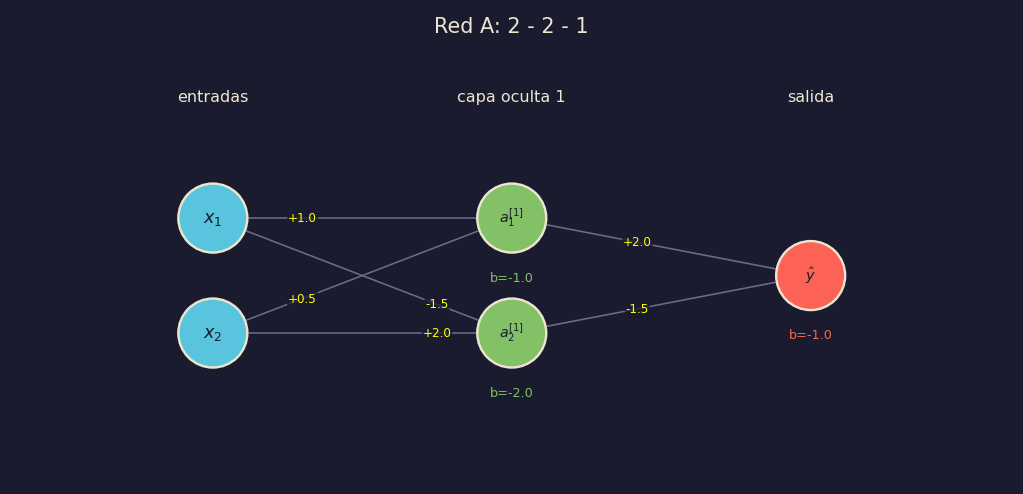

### A.1 — Transcribe los pesos

Lee el diagrama y crea los arreglos. `A_W1` tiene forma `(2, 2)`; `A_W2` tiene forma `(2, 1)`.

In [16]:
# Capa oculta: 2 entradas -> 2 neuronas
A_W1 =np.array([[ 1.0, -1.5],   # pesos desde x1 hacia a1 y a2
                 [ 0.5,  2.0]])  
A_b1 = np.array([-1.0, -2.0])    
# Capa de salida: 2 -> 1
A_W2 = np.array([[ 2.0],         
                 [-1.5]])        
A_b2 = np.array([-1.0]) 

### A.2 — Número de parámetros

Calcula el total de parámetros = (todos los pesos) + (todos los biases). Pista: `W.size` te da cuántos números tiene una matriz.

In [17]:
A_n_params = A_W1.size + A_b1.size + A_W2.size + A_b2.size
print("Parametros Red A:", A_n_params)
# Deberias obtener: 9

Parametros Red A: 9


### A.3 — Forward propagation

Encadena `dense` capa por capa. La Red A tiene **2 capas**: $\vec{a}^{[1]} \to \hat{y}$.

In [18]:
def forward_A(x):
    """x: arreglo (2,)  ->  probabilidad de aprobar."""
    # YOUR CODE HERE: usa dense con (A_W1, A_b1) y luego con (A_W2, A_b2)
    # Capa oculta
    a_hidden = dense(x, A_W1, A_b1)
    # Capa de salida
    y = dense(a_hidden, A_W2, A_b2)
    return y

### A.4 — Prueba tu red

In [6]:
for x in [[2, 6], [5, 5], [8, 1]]:
    p = forward_A(np.array(x, dtype=float))
    print(f"estudio={x[0]}  sueno={x[1]}  ->  p={float(p):.4f}")

# Deberias obtener aprox:
#   estudio=2  sueno=6  ->  p=0.3694   (no aprueba)
#   estudio=5  sueno=5  ->  p=0.5158   (apenas aprueba)
#   estudio=8  sueno=1  ->  p=0.7308   (aprueba)

estudio=2  sueno=6  ->  p=0.3694
estudio=5  sueno=5  ->  p=0.5158
estudio=8  sueno=1  ->  p=0.7308


/tmp/ipykernel_9870/2121402088.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"estudio={x[0]}  sueno={x[1]}  ->  p={float(p):.4f}")


---

## Red B — ¿El correo es spam?  (3 → 4 → 2 → 1)

Clasifica un correo como **spam** (1) o no (0) a partir de:

- $x_1$: número de **enlaces**
- $x_2$: número de palabras en **MAYÚSCULAS**
- $x_3$: menciones de **dinero/premios**

Arquitectura: **3 entradas → oculta de 4 → oculta de 2 → 1 salida**. Lee los pesos:

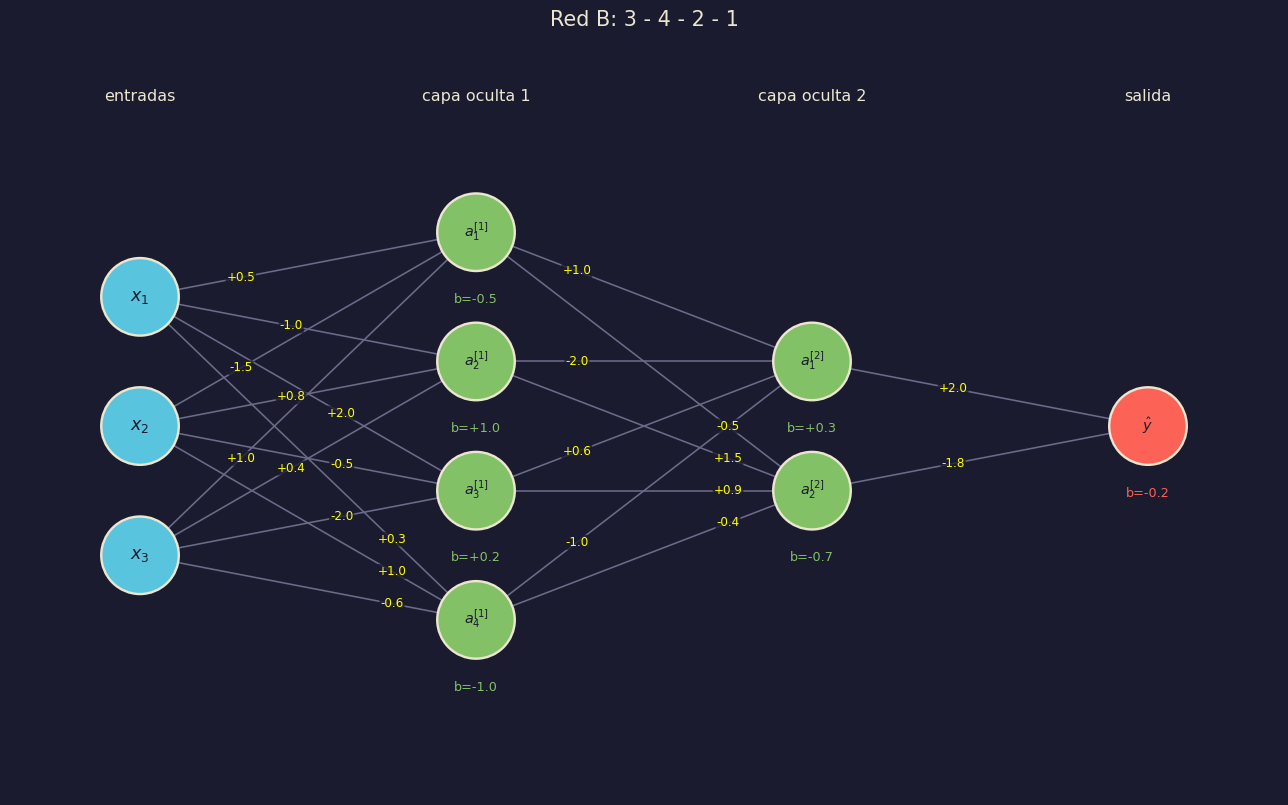

### B.1 — Transcribe los pesos

Formas: `B_W1` `(3, 4)`, `B_b1` `(4,)`, `B_W2` `(4, 2)`, `B_b2` `(2,)`, `B_W3` `(2, 1)`, `B_b3` `(1,)`.

In [7]:
# Capa oculta 1: 3 entradas -> 4 neuronas
B_W1 = np.array([[ 0.5, -1.0, 2.0,0.3],   
        [ -1.5,  0.8, 0.5,1.0],
        [  1.0,  0.4, -2.0,-0.6]])    # forma (3, 4)   # YOUR CODE HERE
B_b1 = np.array([1.0, -2.0,0.6,-1.0])     # forma (4,)
# Capa oculta 2: 4 -> 2
B_W2 = np.array([[ 1.0, -0.5], 
                [  -2.0,  1.5],
                [  0.6,  0.9],
                [  -1.0,  -0.4]])     # forma (4, 2)   # YOUR CODE HERE
B_b2 = np.array([2.0, -1.8])    # forma (2,)
# Capa de salida: 2 -> 1
B_W3 = np.array([[ 2.0], 
                [  -1.8]])   # forma (2, 1)   # YOUR CODE HERE
B_b3 = np.array([-0.2])    # forma (1,)

### B.2 — Número de parámetros

In [8]:
B_n_params = B_W1.size + B_b1.size +B_W2.size +B_b2.size+ B_W3.size +B_b3.size
print("Parametros Red B:", B_n_params)
# Deberias obtener: 29

Parametros Red B: 29


### B.3 — Forward propagation

La Red B tiene **3 capas**: $\vec{a}^{[1]} \to \vec{a}^{[2]} \to \hat{y}$.

In [10]:
def forward_B(x):
    """x: arreglo (3,)  ->  probabilidad de spam."""
    # Capa oculta
    a_hidden = dense(x, B_W1, B_b1)
    b_hidden = dense(a_hidden, B_W2, B_b2)
    y = dense(b_hidden, B_W3, B_b3)
    return y

### B.4 — Prueba tu red

In [11]:
for x in [[1, 3, 0], [2, 1, 1], [3, 0, 2]]:
    p = forward_B(np.array(x, dtype=float))
    print(f"enlaces={x[0]}  mayus={x[1]}  dinero={x[2]}  ->  p={float(p):.4f}")

# Deberias obtener aprox:
#   enlaces=1  mayus=3  dinero=0  ->  p=0.2226   (no spam)
#   enlaces=2  mayus=1  dinero=1  ->  p=0.3922   (no spam)
#   enlaces=3  mayus=0  dinero=2  ->  p=0.6114   (spam)

enlaces=1  mayus=3  dinero=0  ->  p=0.6683
enlaces=2  mayus=1  dinero=1  ->  p=0.7932
enlaces=3  mayus=0  dinero=2  ->  p=0.8032


/tmp/ipykernel_9870/2199352188.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"enlaces={x[0]}  mayus={x[1]}  dinero={x[2]}  ->  p={float(p):.4f}")


---

## Red C — ¿Transacción fraudulenta?  (4 → 3 → 3 → 2 → 1)

Detecta si una transacción con tarjeta es **fraude** (1) o no (0) a partir de:

- $x_1$: **monto** (en miles)
- $x_2$: **hora** del día (0–3, codificada)
- $x_3$: número de **transacciones recientes**
- $x_4$: **distancia** al domicilio

Arquitectura: **4 entradas → oculta de 3 → oculta de 3 → oculta de 2 → 1 salida**. Lee los pesos:

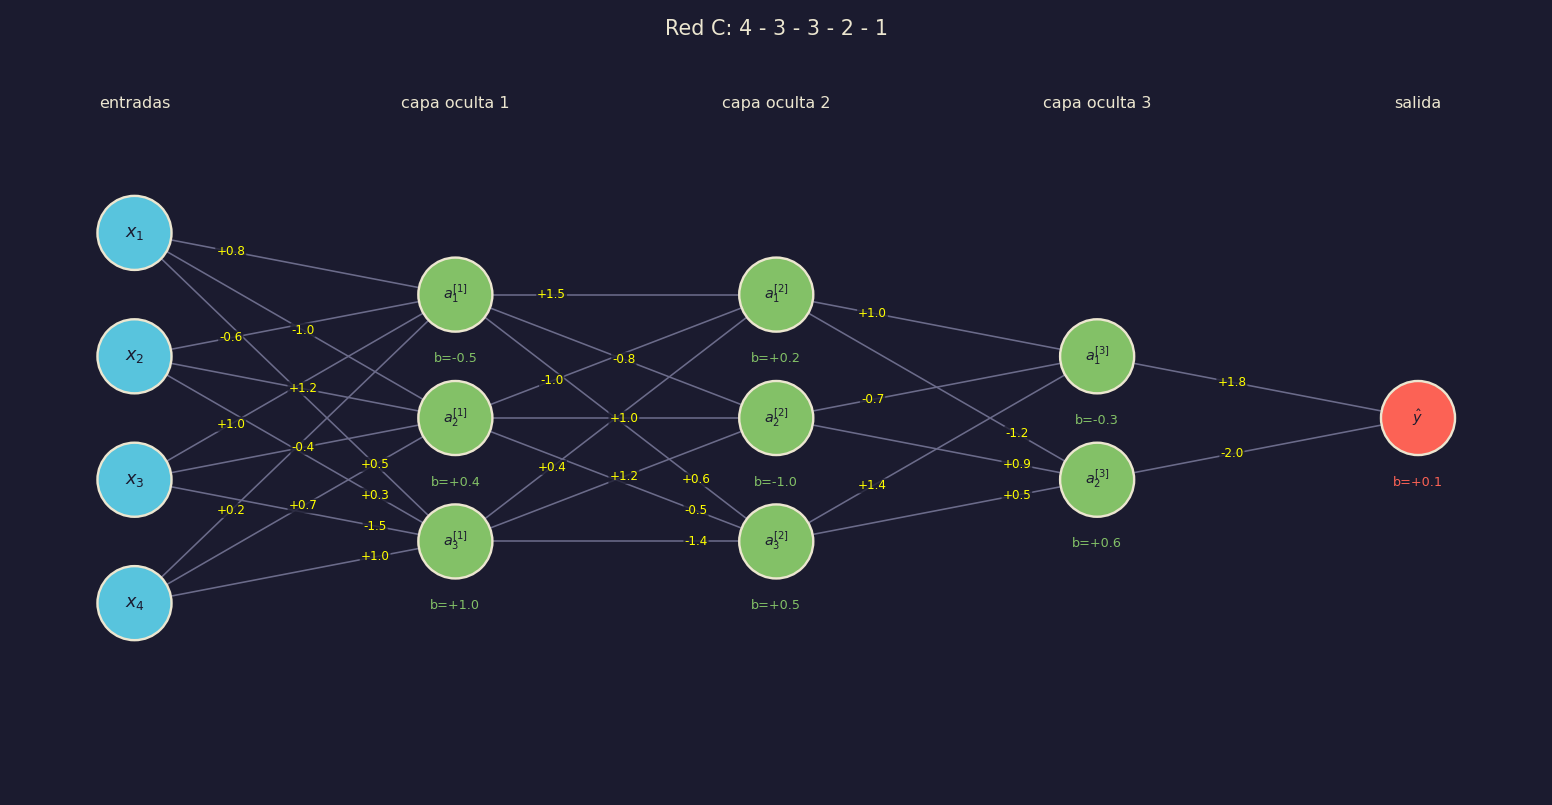

### C.1 — Transcribe los pesos

Formas: `C_W1` `(4, 3)`, `C_b1` `(3,)`, `C_W2` `(3, 3)`, `C_b2` `(3,)`, `C_W3` `(3, 2)`, `C_b3` `(2,)`, `C_W4` `(2, 1)`, `C_b4` `(1,)`.

In [12]:

C_W1 = np.array([
    [0.8,  1.5,  0.0],   # pesos desde x1
    [-0.6, -1.0,  1.2],  # pesos desde x2
    [1.0,  0.4,  0.5],   # pesos desde x3
    [0.2,  0.7, -1.5]    # pesos desde x4
])   # forma (4, 3)
C_b1 = np.array([-0.5, 0.4, 1.0])   # forma (3,)

C_W2 = np.array([
    [-0.8, -1.0,  0.4],
    [ 1.2, -0.5, -1.4],
    [ 1.0, -0.7,  1.4]
])   # forma (3, 3)
C_b2 = np.array([0.2, 1.0, 0.5])    # forma (3,)


C_W3 = np.array([
    [-1.2,  0.9],
    [ 0.5,  1.8],
    [-2.0,  0.0]
])   # forma (3, 2)
C_b3 = np.array([-0.3, 0.6])        # forma (2,)


C_W4 = np.array([
    [1.0],
    [-0.5]
])   # forma (2, 1)
C_b4 = np.array([0.1])  

### C.2 — Número de parámetros

In [13]:
C_n_params = (C_W1.size + C_b1.size +
              C_W2.size + C_b2.size +
              C_W3.size + C_b3.size +
              C_W4.size + C_b4.size)
print("Parametros Red C:", C_n_params)
# Deberias obtener: 38

Parametros Red C: 38


### C.3 — Forward propagation

La Red C tiene **4 capas**: $\vec{a}^{[1]} \to \vec{a}^{[2]} \to \vec{a}^{[3]} \to \hat{y}$.

In [14]:
def forward_C(x):
    """x: arreglo (4,)  ->  probabilidad de fraude."""
    a1 = dense(x, C_W1, C_b1)   # capa oculta 1
    a2 = dense(a1, C_W2, C_b2)  # capa oculta 2
    a3 = dense(a2, C_W3, C_b3)  # capa oculta 3
    y  = dense(a3, C_W4, C_b4)  # salida
    return y

### C.4 — Prueba tu red

In [15]:
for x in [[0, 3, 0, 1], [1, 1, 1, 1], [3, 0, 3, 0]]:
    p = forward_C(np.array(x, dtype=float))
    print(f"x={x}  ->  p={float(p):.4f}")

# Deberias obtener aprox:
#   x=[0, 3, 0, 1]  ->  p=0.3936   (no fraude)
#   x=[1, 1, 1, 1]  ->  p=0.5109   (frontera)
#   x=[3, 0, 3, 0]  ->  p=0.6247   (fraude)

x=[0, 3, 0, 1]  ->  p=0.4287
x=[1, 1, 1, 1]  ->  p=0.4368
x=[3, 0, 3, 0]  ->  p=0.4367


/tmp/ipykernel_9870/2859525198.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"x={x}  ->  p={float(p):.4f}")


---

## ¡Felicidades! 🎉

Implementaste la **inferencia** (forward propagation) de tres redes neuronales de distinto tamaño, usando solo **NumPy** y **multiplicación matricial**:

- Leíste los pesos directamente del **diagrama** de cada red.
- Contaste sus **parámetros** (9, 29 y 38).
- Encadenaste la función `dense` **capa por capa**.

**Idea clave:** sin importar cuántas entradas, capas o neuronas tenga la red, la inferencia es siempre lo mismo — propagar la entrada hacia adelante con una **multiplicación matricial por capa** (que no es más que muchos **productos punto** a la vez) seguida de la activación. El **entrenamiento** —encontrar esos pesos— es el tema de la siguiente unidad.

*Material de Universidad Galileo / adaptado de DeepLearning.AI (CC BY-SA 2.0).*